# 28 · Transaction Costs: The Almgren-Chriss Model and Turnover Optimization

*Module 6 — Risk Management*

A brilliant strategy that trades too aggressively can lose more to its own market impact than it ever earned from its edge. This notebook builds the classic framework for finding the trading speed that minimizes total cost — and shows how to stop a portfolio optimizer from ever demanding that much trading in the first place.

## 1. Motivation

Notebook 1 showed that a large order "walks the book," paying a worse average price the faster and larger it trades. Notebook 5 showed that naive portfolio optimization can demand wild, unstable swings in position sizes. Put the two together and you get one of the most quietly destructive forces in quantitative trading: a strategy with a genuine edge, implemented by a portfolio process that rebalances aggressively, can lose more to the accumulated cost of *executing* its own trades than it ever earned from being right. This notebook builds the tools to reason about that cost precisely, and to design portfolios that respect it from the start rather than discovering it after the fact.

## 2. Intuition

Trading costs come in two structurally different flavors. **Temporary impact** is the cost of demanding liquidity faster than the market wants to supply it right now — pay more to trade quickly, but the price snaps back afterward, exactly like Notebook 1's price-impact curve. **Permanent impact** is different: it is the part of the price move that *sticks*, reflecting that your trading itself has revealed information or genuinely shifted the supply-demand balance.

This creates a genuine trade-off, not just a cost to be minimized in isolation. Trade a large order *very slowly* to keep temporary impact low, and you are exposed to ordinary price risk for a long time — the market could move against you for entirely unrelated reasons while you are still only partway done. Trade *very fast* to minimize that timing risk, and you pay dearly in temporary impact. The Almgren-Chriss framework finds the trading speed that best balances these two costs, given how risk-averse you are about the uncertainty of the slower alternative.

The same logic, one level up, applies to an entire portfolio's ongoing rebalancing: an optimizer that only cares about expected return and risk, with no awareness that changing weights costs money, will happily recommend large trades for only a marginal improvement in the portfolio — unless you explicitly tell it that turnover itself is costly.

## 3. Theory

### 3.1 The Almgren-Chriss setup

Liquidate $X$ shares over $[0,T]$, with a trading trajectory $x_t$ (shares remaining, $x_0=X$, $x_T=0$) and trading rate $v_t=-\dot x_t$. Assume:

- **Permanent impact**: linear in trading rate, moving the reference price by $\gamma v_t$ per unit time, contributing a total cost that (in the simplest linear specification) depends only on the total quantity traded, $\tfrac12\gamma X^2$, regardless of the trajectory's shape.
- **Temporary impact**: an additional, transient cost of $\eta v_t$ per share sold, only paid while actively trading, contributing total cost $\eta\int_0^T v_t^2\,dt$ — note this is **quadratic** in trading rate, directly penalizing trading too fast.
- **Timing risk**: while shares remain unsold, they are exposed to ordinary price volatility $\sigma$, contributing variance $\sigma^2\int_0^T x_t^2\,dt$ to the total execution cost — penalizing trading too *slowly*.

### 3.2 The optimal trajectory

Minimizing expected cost plus $\lambda$ times its variance (a standard mean-variance objective, $\lambda$ representing risk aversion to execution uncertainty) leads, via a calculus-of-variations argument we will not re-derive in full here, to the classic Almgren-Chriss result:

$$
x_t = X\,\frac{\sinh\big(\kappa(T-t)\big)}{\sinh(\kappa T)}, \qquad \kappa = \sqrt{\lambda\sigma^2/\eta} .
$$

**A check we can do rigorously ourselves**: as risk aversion $\lambda\to0$ (purely cost-minimizing, ignoring timing risk entirely), $\kappa\to0$, and using $\sinh(z)\approx z$ for small $z$:

$$
x_t \to X\,\frac{\kappa(T-t)}{\kappa T} = X\Big(1-\frac{t}{T}\Big) ,
$$

exactly a **linear** trajectory — equal-sized trades spread evenly over time, precisely Notebook 3's TWAP execution style. This is a genuinely useful sanity check: the general formula collapses to a well-understood special case exactly where intuition says it should. As $\lambda$ (and therefore $\kappa$) grows, the trajectory becomes increasingly **front-loaded** — trade a larger fraction early, to reduce the time spent exposed to price risk, accepting higher market-impact cost in exchange.

### 3.3 Turnover-penalized portfolio optimization

Given a portfolio optimization objective (Notebook 5's mean-variance framework), add an explicit penalty for trading away from the current weights $w_{prev}$:

$$
\max_w \; w^\top\mu - \tfrac{1}{2}\theta\, w^\top\Sigma w - c\sum_i |w_i - w_{prev,i}| ,
$$

where $c$ is a per-unit-turnover cost. This directly discourages the optimizer from chasing small, estimation-noise-driven improvements (recall Notebook 5's whole error-maximization theme) that are not large enough to justify their trading cost — a very direct, practical antidote to exactly the instability that notebook diagnosed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(171)

## 4. Implementation

### 4.1 The optimal trajectory, and verifying the risk-neutral limit ourselves

Max difference between kappa->0 and the exact linear formula: 6.41e-09  (should be essentially zero -- confirms the limit derived in Section 3.2)


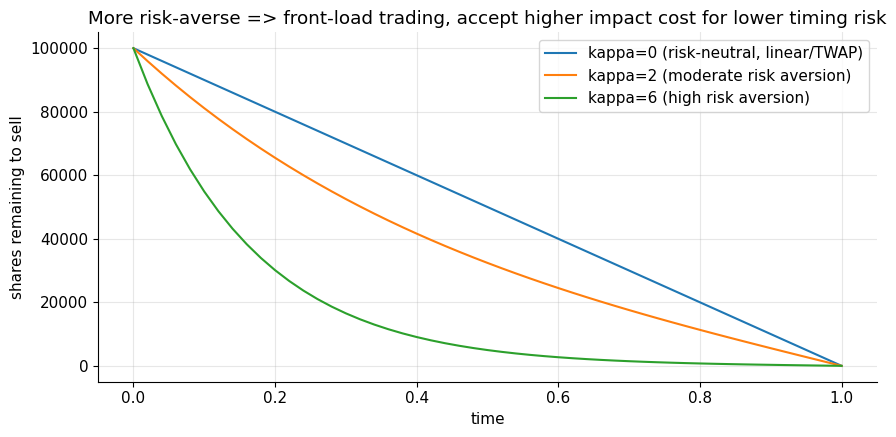

In [2]:
def ac_trajectory(X, T, n_steps, kappa):
    t = np.linspace(0, T, n_steps + 1)
    if kappa < 1e-8:
        x = X * (1 - t / T)
    else:
        x = X * np.sinh(kappa * (T - t)) / np.sinh(kappa * T)
    return t, x

X, T, n_steps = 100_000, 1.0, 50

t_a, x_tiny_kappa = ac_trajectory(X, T, n_steps, kappa=1e-6)
t_b, x_exact_linear = ac_trajectory(X, T, n_steps, kappa=0.0)
print(f"Max difference between kappa->0 and the exact linear formula: {np.max(np.abs(x_tiny_kappa - x_exact_linear)):.2e}"
      f"  (should be essentially zero -- confirms the limit derived in Section 3.2)")

fig, ax = plt.subplots()
for kappa, label, color in [(0, 'kappa=0 (risk-neutral, linear/TWAP)', '#264653'),
                              (2, 'kappa=2 (moderate risk aversion)', '#2a9d8f'),
                              (6, 'kappa=6 (high risk aversion)', '#e76f51')]:
    t_, x_ = ac_trajectory(X, T, n_steps, kappa)
    ax.plot(t_, x_, label=label)
ax.set_xlabel('time')
ax.set_ylabel('shares remaining to sell')
ax.set_title('More risk-averse => front-load trading, accept higher impact cost for lower timing risk')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 The cost/risk trade-off, quantified

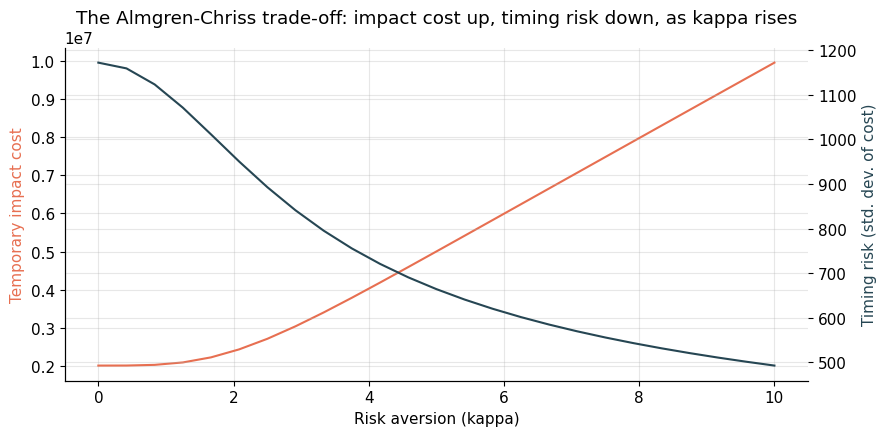

In [3]:
ETA, GAMMA_PERM, SIGMA = 0.0002, 0.0001, 0.02   # illustrative temporary-impact, permanent-impact, and volatility parameters

def ac_cost_components(X, T, n_steps, kappa, eta, gamma_perm, sigma):
    t, x = ac_trajectory(X, T, n_steps, kappa)
    dt = T / n_steps
    v = -np.diff(x) / dt
    perm_cost = 0.5 * gamma_perm * X**2                     # depends only on total X, not the trajectory shape
    temp_cost = eta * np.sum(v**2) * dt                       # penalizes trading FAST
    timing_variance = sigma**2 * np.sum(x[:-1]**2) * dt        # penalizes trading SLOW (more time exposed to risk)
    return perm_cost, temp_cost, timing_variance

kappas = np.linspace(0, 10, 25)
rows = []
for kappa in kappas:
    pc, tc, var = ac_cost_components(X, T, n_steps, kappa, ETA, GAMMA_PERM, SIGMA)
    rows.append({'kappa': kappa, 'temporary_impact_cost': tc, 'timing_risk_std': np.sqrt(var)})
tradeoff = pd.DataFrame(rows)

fig, ax1 = plt.subplots()
ax1.plot(tradeoff['kappa'], tradeoff['temporary_impact_cost'], color='#e76f51')
ax1.set_xlabel('Risk aversion (kappa)')
ax1.set_ylabel('Temporary impact cost', color='#e76f51')
ax2 = ax1.twinx()
ax2.plot(tradeoff['kappa'], tradeoff['timing_risk_std'], color='#264653')
ax2.set_ylabel('Timing risk (std. dev. of cost)', color='#264653')
ax1.set_title('The Almgren-Chriss trade-off: impact cost up, timing risk down, as kappa rises')
plt.tight_layout()
plt.show()

## 5. Worked example: turnover-penalized portfolio optimization

Reusing Module 2's 8-asset universe: starting from an equal-weight portfolio, how much does explicitly penalizing turnover change the optimizer's recommended trades?

In [4]:
TICKERS = ['GALP', 'EDP', 'JMT', 'BCP', 'NOS', 'SEM', 'SPY', 'IEF']
N = len(TICKERS)
TRUE_ANN_VOL = np.array([0.26, 0.24, 0.22, 0.28, 0.30, 0.32, 0.16, 0.06])
TRUE_ANN_MU = np.array([0.090, 0.080, 0.075, 0.070, 0.065, 0.060, 0.080, 0.030])
corr = np.eye(N)
for i in range(6):
    for j in range(6):
        if i != j:
            corr[i, j] = 0.45
for i in range(6):
    corr[i, 6] = corr[6, i] = 0.30
    corr[i, 7] = corr[7, i] = -0.05
corr[6, 7] = corr[7, 6] = -0.10
Sigma = np.diag(TRUE_ANN_VOL) @ corr @ np.diag(TRUE_ANN_VOL)

w_current = np.ones(N) / N

def objective(w, mu, Sigma, w_prev, risk_aversion, turnover_cost):
    ret = w @ mu
    risk = w @ Sigma @ w
    turnover = np.sum(np.abs(w - w_prev))
    return -(ret - 0.5*risk_aversion*risk - turnover_cost*turnover)

turnover_costs = [0.0, 0.02, 0.05, 0.15]
rows = []
for c in turnover_costs:
    res = minimize(objective, w_current, args=(TRUE_ANN_MU, Sigma, w_current, 3.0, c),
                    method='SLSQP', bounds=[(0, 1)]*N,
                    constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}])
    turnover = np.sum(np.abs(res.x - w_current))
    rows.append({'turnover_cost': c, 'turnover': turnover, 'expected_return': res.x @ TRUE_ANN_MU, 'weights': res.x})

summary = pd.DataFrame(rows)
summary[['turnover_cost', 'turnover', 'expected_return']].round(4)

,turnover_cost,turnover,expected_return
0,0.00,0.9029,0.0719
1,0.02,0.4836,0.0728
2,0.05,0.0000,0.0687
3,0.15,0.0000,0.0687


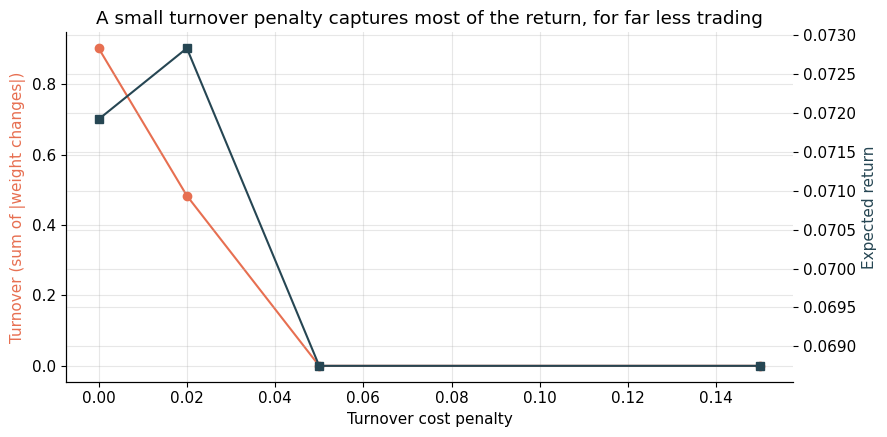

In [5]:
fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(summary['turnover_cost'], summary['turnover'], 'o-', color='#e76f51', label='turnover')
ax2.plot(summary['turnover_cost'], summary['expected_return'], 's-', color='#264653', label='expected return')
ax.set_xlabel('Turnover cost penalty')
ax.set_ylabel('Turnover (sum of |weight changes|)', color='#e76f51')
ax2.set_ylabel('Expected return', color='#264653')
ax.set_title('A small turnover penalty captures most of the return, for far less trading')
plt.tight_layout()
plt.show()

### Interpreting the result

The pattern in the chart is the entire practical case for turnover penalization: expected return barely moves across the range of turnover penalties tested, while turnover itself collapses sharply once even a modest cost is introduced. Most of the "improvement" a completely turnover-blind optimizer chases is exactly the kind of estimation-noise-driven churn Notebook 5 warned about — trading heavily for a return benefit that is mostly not real, and even where it is real, is often not large enough to be worth the transaction costs Notebook 1's price-impact mechanics guarantee it will actually incur.

## 6. Limitations and pitfalls

- **The linear-impact assumptions are a simplification.** Notebook 2's discussion of the empirically-observed "square-root law" of price impact suggests real impact often scales as $\sqrt{v}$ rather than linearly in $v$ — the Almgren-Chriss framework has extensions for nonlinear impact, but the clean closed-form trajectory used here specifically relies on the linear-quadratic structure.
- **Impact parameters ($\eta,\gamma$) must themselves be estimated**, typically from historical execution data, and are asset- and regime-specific — using stale or poorly-calibrated impact parameters can make an "optimal" trajectory optimal for the wrong cost structure entirely.
- **The framework assumes you are the only strategic trader**, with a purely mechanical price response to your own trading. It says nothing about adverse selection or information leakage (Notebook 4's territory) — other participants inferring your trading intentions from the pattern of your own execution and trading ahead of you is a real, separate risk this model does not capture.
- **Turnover penalization in Section 5 uses a single scalar cost `c` for every asset.** Real transaction costs vary enormously by instrument (Notebook 2's Amihud illiquidity ranking directly implies this) — a more realistic implementation would use asset-specific costs, penalizing trading in illiquid names more heavily than liquid ones.
- **This is a single-period optimization** re-solved at each rebalance; it does not explicitly account for the fact that today's trade affects tomorrow's optimal starting point, a genuinely dynamic, multi-period problem that a repeated single-period turnover penalty only approximates.

## 7. Exercises

**1. How much does trading speed matter for cost alone? (warm-up)**
Using `ac_cost_components`, compute total cost (permanent + temporary, ignoring timing risk) for `kappa=0` (a full TWAP-style linear liquidation) versus liquidating the entire position in a single instant (`n_steps=1`). How many times larger is the instant-liquidation temporary impact cost? Does this match the intuition from Notebook 1's price-impact curve?

**2. A less risk-averse trader in a more volatile market.**
Recompute the Section 4.2 trade-off curve (`temporary_impact_cost` and `timing_risk_std` against `kappa`) with `SIGMA` doubled. Does the optimal-looking `kappa` (where the two costs feel roughly balanced to you) shift higher or lower when volatility rises? Explain why, referencing the definition $\kappa=\sqrt{\lambda\sigma^2/\eta}$.

**3. Asset-specific turnover costs.**
Modify Section 5's turnover penalty so that each asset has its own cost, proportional to its inverse average dollar volume (reuse the liquidity intuition, and even the specific ticker ordering, from Notebook 2's Amihud ranking — e.g., assign `SEM` and `NOS` a materially higher per-unit turnover cost than `SPY` or `GALP`). Re-run the optimization across the same range of overall cost scaling. Does the optimizer now avoid trading the illiquid names specifically, while still trading the liquid ones more freely, compared to the single-scalar-cost version?